# Lecture 1 - Python and Scientific Computing Foundations

This notebook contains my own implementations and notes while learning Python for Physics-Informed Neural Networks.

In [3]:
import sys # to access the version of the installed Python
sys.version # checking the Python version

'3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]'

In [4]:
import numpy as np
print("Numpy version:", np.__version__)

Numpy version: 2.4.4


In [5]:
import matplotlib.pyplot as plt
import matplotlib

print("Matplotlib version:", matplotlib.__version__)

Matplotlib version: 3.10.9


In [6]:
length = 2.0
width = 0.5
thickness = 0.01

volume = length * width * thickness

print("Length:", length, "m")
print("Width:", width, "m")
print("Thickness:", thickness, "m")
print("Volume:", volume, "m³")

Length: 2.0 m
Width: 0.5 m
Thickness: 0.01 m
Volume: 0.01 m³


In [7]:
density = 7850.0
material = "steel"
is_solid = True

mass = density * volume

print("Material:", material)
print("Density:", density, "kg/m^3")
print("Mass:", mass, "kg")
print("Is the material solid?", is_solid)

print(type(density))
print(type(material))
print(type(is_solid))

Material: steel
Density: 7850.0 kg/m^3
Mass: 78.5 kg
Is the material solid? True
<class 'float'>
<class 'str'>
<class 'bool'>


In [8]:
youngs_modulus = 210e9
applied_stress = 150e6
yield_strength = 355e6

strain = applied_stress / youngs_modulus
is_below_yield = applied_stress < yield_strength

print("Applied stress:", applied_stress / 1e6, "MPa")
print("Elastic strain:", strain)
print("Stress is below yield strength:", is_below_yield)

Applied stress: 150.0 MPa
Elastic strain: 0.0007142857142857143
Stress is below yield strength: True


In [9]:
if applied_stress < yield_strength:
    material_state = "elastic"

elif applied_stress == yield_strength:
    material_state = "at yield"

else:
    material_state = "plastic or nonlinear response expected"

print("Material state:", material_state)

Material state: elastic


In [10]:
temperatures_celcius = [20.0, 40.0, 60.0, 80.0]

for temp_c in temperatures_celcius:
    temperature_kelvin = temp_c + 273.15

    print(temp_c, "°C =", temperature_kelvin, "K")

20.0 °C = 293.15 K
40.0 °C = 313.15 K
60.0 °C = 333.15 K
80.0 °C = 353.15 K


In [11]:
time_seconds = 0

while time_seconds <= 5:
    print("Time:", time_seconds, "s")
    time_seconds += 1

Time: 0 s
Time: 1 s
Time: 2 s
Time: 3 s
Time: 4 s
Time: 5 s


In [12]:
def calculate_axial_stress(force_newtons, area_square_meters):
    if area_square_meters <= 0: # we make the value test as mathematically correct or not
        raise ValueError("Cross-sectional area must be greater than zero.") # when the function has a meaningful error, so this line comes out basically.

    stress_pascals = force_newtons / area_square_meters
    return stress_pascals

In [13]:
force = 50000.0
area = 250e-6

stress = calculate_axial_stress(force, area)

print("Axial stress:", stress, "Pa")
print("Axial stress:", stress / 1e6, "MPa")

Axial stress: 200000000.0 Pa
Axial stress: 200.0 MPa


In [14]:
positions = np.array([0.0, 0.25, 0.50, 0.75, 1.0])

print("Positions:", positions)
print("Array type:", type(positions))
print("Array shape:", positions.shape)
print("Number of dimensions:", positions.ndim)
print("Number of elements:", positions.size)

Positions: [0.   0.25 0.5  0.75 1.  ]
Array type: <class 'numpy.ndarray'>
Array shape: (5,)
Number of dimensions: 1
Number of elements: 5


In [15]:
positions = np.array([0.0, 0.25, 0.50, 0.75, 1.0])

first_position = positions[0]
third_position = positions[2]
last_position = positions[-1]

middle_positions = positions[1:4]

print("First position:", first_position)
print("Third position:", third_position)
print("Last position:", last_position)
print("Middle position:", middle_positions)

First position: 0.0
Third position: 0.5
Last position: 1.0
Middle position: [0.25 0.5  0.75]


In [16]:
# Vectorized Array Calculations

positions = np.array([0.0, 0.25, 0.50, 0.75, 1.0]) # like x = 0.0, 0.25,... 1.0

displacements = positions**2 + 2.0 * positions + 1.0  # u(x) = x^2 + 2*x + 1

print("Positions:", positions)
print("Displacements:", displacements)

Positions: [0.   0.25 0.5  0.75 1.  ]
Displacements: [1.     1.5625 2.25   3.0625 4.    ]


In [17]:
displacements_loop = []

for position in positions:
    displacement = position**2 + 2.0* position + 1.0
    displacements_loop.append(displacement)

displacements_loop = np.array(displacements_loop)

print("Vectorized result:", displacements)
print("Loop results:", displacements_loop)
print("Results are equal:", np.allclose(displacements, displacements_loop))


Vectorized result: [1.     1.5625 2.25   3.0625 4.    ]
Loop results: [1.     1.5625 2.25   3.0625 4.    ]
Results are equal: True


In [18]:
x = np.linspace(0.0, 1.0, 11)

print("x values:", x)
print("Number of points:", x.size)
print("First point:", x[0])
print("Last point:", x[-1])

x values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of points: 11
First point: 0.0
Last point: 1.0


In [19]:
x_column = x.reshape(-1,1) # changes into 2 dimensional array, 11 rows and 1 column

print("Original array:")
print(x)
print("Original shape:", x.shape)

print("\nColumn vector:")
print(x_column)
print("Column-vector shape:", x_column.shape)

Original array:
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Original shape: (11,)

Column vector:
[[0. ]
 [0.1]
 [0.2]
 [0.3]
 [0.4]
 [0.5]
 [0.6]
 [0.7]
 [0.8]
 [0.9]
 [1. ]]
Column-vector shape: (11, 1)


In [20]:
x = np.linspace(0.0, 1.0, 11)

right_half_mask = x >= 0.5
right_half_points = x[right_half_mask]

print("x values:", x)
print("Boolean mask:", right_half_mask)
print("Points where x >= 0.5:", right_half_points)

x values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Boolean mask: [False False False False False  True  True  True  True  True  True]
Points where x >= 0.5: [0.5 0.6 0.7 0.8 0.9 1. ]


In [21]:
# Define physical field by python

x = np.linspace(0.0, 1.0, 101)

u = np.sin(np.pi * x) # u(x) = sin(pi * x)

print("First five x values:")
print(x[:5])

print("\nFirst five u values:")
print(u[:5])

print("\nBoundary values:")
print("u(0) =", u[0])
print("u(1) =", u[-1])

First five x values:
[0.   0.01 0.02 0.03 0.04]

First five u values:
[0.         0.03141076 0.06279052 0.09410831 0.12533323]

Boundary values:
u(0) = 0.0
u(1) = 1.2246467991473532e-16


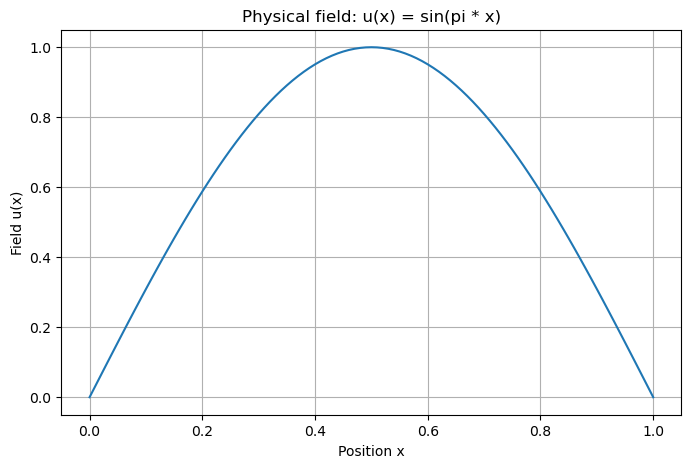

In [22]:
# Plotting
plt.figure(figsize=(8,5)) # creates new figure. The size is 8 inches wide and 5 inches high

plt.plot(x,u) # x is horizontal and u is vertical axis on the plot

plt.xlabel("Position x") # adding label and title
plt.ylabel("Field u(x)")
plt.title("Physical field: u(x) = sin(pi * x)")

plt.grid(True) # adds grid lines
plt.show() # display the finished graph

In [ ]:
def physical_field(x_values):
    u_values = np.sin(np.pi * x_values)
    return u_values

x_test = np.linspace(0.0,1.0,5)

u_test = physical_field(x_test)

print("x values: ", x_test)
print("u values: ", u_test)
print("u(0.5) = ", physical_field(0.5))

x values:  [0.   0.25 0.5  0.75 1.  ]
u values:  [0.00000000e+00 7.07106781e-01 1.00000000e+00 7.07106781e-01
 1.22464680e-16]
u(0.5) =  1.0


In [ ]:
# Approximate the first derivative (finite difference)

# central difference formula will be used u'(x) = u(x + h) - u(x - h) / 2*h

def first_derivative(function, x_values, step_size):
    value_forward = function(x_values + step_size) # (x+h) - (x-h) = 2h
    value_backward = function(x_values - step_size)

    # function: the function we want to differentiate
    # x_values: the positions where the derivative is calculated
    # step_size: the small numerical distance h

    derivative = (value_forward - value_backward) / (2.0 * step_size)

    return derivative

In [34]:
x_derivative = np.linspace(0.0, 1.0, 101)
step_size = 1e-5

du_numeric = first_derivative(
    physical_field,
    x_derivative,
    step_size
)

print("First five numerical derivative values: ")
print(du_numeric[:5])

First five numerical derivative values: 
[3.14159265 3.14004247 3.13539344 3.12765015 3.11682026]


In [35]:
# Define the analytical derivative (exact solution)

def analytical_first_derivative(x_values):
    derivative_values = np.pi * np.cos(np.pi * x_values) # u'(x) = pi * cos(pi * x)
    return derivative_values

In [36]:
du_exact = analytical_first_derivative(x_derivative)

print("First five analytical derivative values:")
print(du_exact[:5])

First five analytical derivative values:
[3.14159265 3.14004247 3.13539344 3.12765015 3.11682026]


In [37]:
# Calculate Derivative Error

absolute_error = np.abs(du_numeric - du_exact)

maximum_error = np.max(du_numeric - du_exact)
mean_error = np.mean(absolute_error)

print("Maximum absolute error:", maximum_error)
print("Mean absolute error:", mean_error)

Maximum absolute error: 5.510765177518806e-10
Mean absolute error: 3.350037781367991e-10


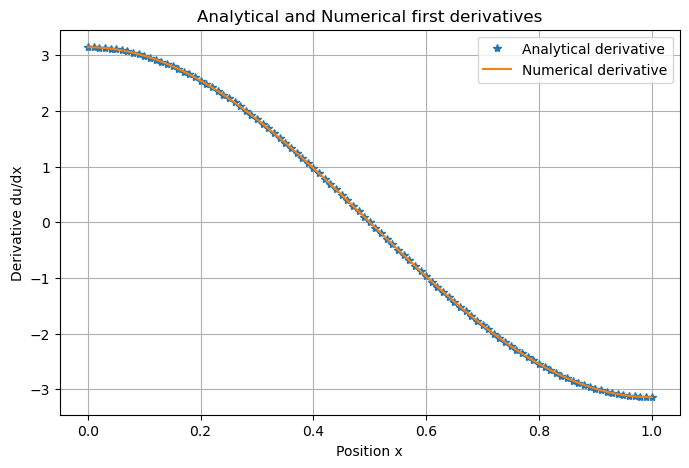

In [45]:
# Plot Numerical and Analytical derivatives

plt.figure(figsize=(8,5))

plt.plot(x_derivative, du_exact, "*" ,label = "Analytical derivative")
plt.plot(x_derivative, du_numeric, "-" ,label = "Numerical derivative")

plt.xlabel("Position x")
plt.ylabel("Derivative du/dx")
plt.title("Analytical and Numerical first derivatives")

plt.grid(True)
plt.legend()
plt.show()

In [47]:
step_sizes = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

maximum_errors = []

for step_size in step_sizes:

    du_numeric_test = first_derivative(physical_field, x_derivative, step_size)

    absolute_error_test = np.abs(du_numeric_test - du_exact)

    maximum_error_test = np.max(absolute_error_test)

    maximum_errors.append(maximum_error_test)

    print("Step size:", step_size, "Maximum error:", maximum_error_test)

# we observe that the error decreases as h becomes smaller, however extremely small values of h can eventually increase floating-point round-off error. This trade-off is important in numerical methods

Step size: 0.1 Maximum error: 0.05142270984031949
Step size: 0.01 Maximum error: 0.0005167457769821304
Step size: 0.001 Maximum error: 5.167710425801886e-06
Step size: 0.0001 Maximum error: 5.1677127910210174e-08
Step size: 1e-05 Maximum error: 5.510765177518806e-10
Step size: 1e-06 Maximum error: 2.398419240989824e-10


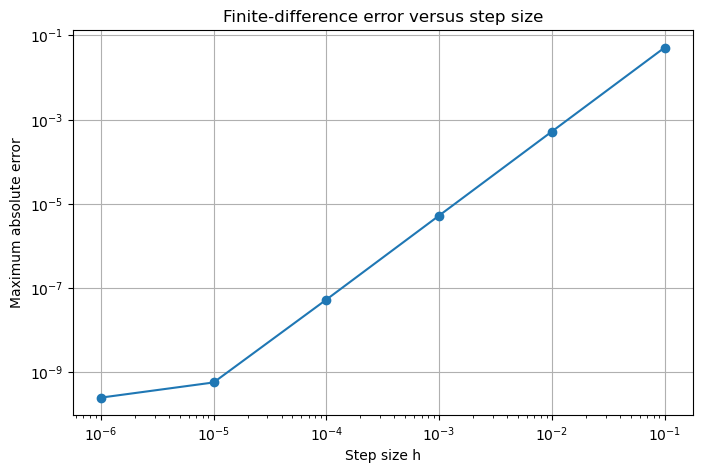

In [50]:
# Plot error versus step size

plt.figure(figsize=(8,5))

plt.loglog(step_sizes, maximum_errors, marker = "o")

plt.xlabel("Step size h")
plt.ylabel("Maximum absolute error")
plt.title("Finite-difference error versus step size")

plt.grid(True)
plt.show()

# we observe the error decreasing as h becomes smaller. Later, for extremely small h, floating-point round-off can prevent further improvement

In [ ]:
# Define the second derivative

# Central second-difference formula

def second_derivative(function, x_values, step_size):
    value_forward = function(x_values + step_size)
    value_center = function(x_values)
    value_backward = function(x_values - step_size)

    derivative = (value_forward - 2.0 * value_center + value_backward) / step_size**2

    return derivative

In [ ]:
x_second_derivative = np.linspace(0.0, 1.0, 101)
second_derivative_step = 1e-4

d2u_numeric = second_derivative(physical_field, x_second_derivative, second_derivative_step)

print("First five numerical second-derivative values:")
print(d2u_numeric[:5])

# How the formula works:
# At each point x, the function uses three values:

# u(x+h): slightly to the right
# u(x): at the current point
# u(x-h): slightly to the left

First five numerical second-derivative values:
[ 0.         -0.31001176 -0.61971758 -0.92881181 -1.23698942]


In [62]:
# Calculate the differential-equation residual
# We now test whether the field satisfies: u''(x) + pi^2*u(x) = 0

# A residual measures how much a proposed function violates a differential equation.

# residual = error in satisfying the governing equation

u_values = physical_field(x_second_derivative)

residual = (d2u_numeric + np.pi**2 * u_values)

maximum_residual = np.max(np.abs(residual))

print("First five residual values:")
print(residual[:5])

print("Maximum absolute residual:", maximum_residual)

# train the neural network so that this residual becomes small. This is how the governing differential equation enters the training process

First five residual values:
[0.00000000e+00 2.55660965e-09 7.16887694e-09 8.34776492e-09
 8.80911810e-09]
Maximum absolute residual: 1.0193837951533169e-07


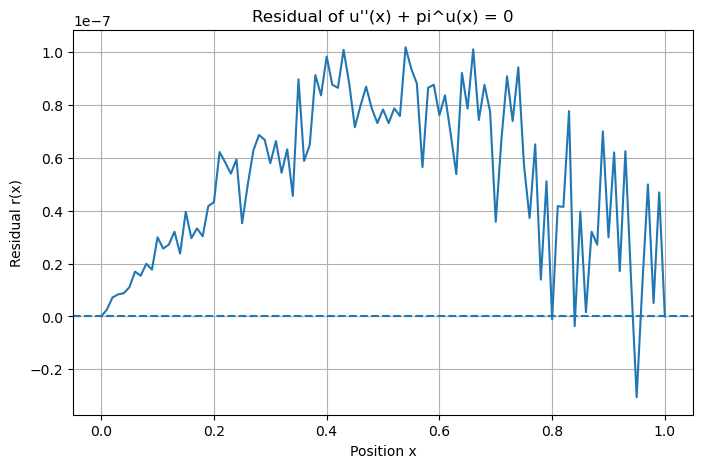

In [64]:
plt.figure(figsize=(8,5))

plt.plot(x_second_derivative, residual)

plt.axhline(y = 0.0, linestyle = "--")

plt.xlabel("Position x")
plt.ylabel("Residual r(x)")
plt.title("Residual of u''(x) + pi^u(x) = 0")

plt.grid(True)
plt.show()

In [ ]:
# Convert the residual into a physics loss
# A residual gives one error value at every point. A loss combines all those values into one scalar number.

physics_loss = np.mean(residual**2)
print("Physics loss:", physics_loss)

# squares every residual value

# positive and negative residuals cannot cancel each other
# larger viaolations receive a stronger penalty
# the final values are non-negative

Physics loss: 3.6826242650254004e-15


In [ ]:
# The boundary-condition loss
# Our differential equation also has boundary conditions
# u(0) = 0 and u(1) = 0

boundary_points = np.array([0.0, 1.0])

boundary_values = physical_field(boundary_points)
boundary_loss = np.mean(boundary_values ** 2)

total_loss = physics_loss + boundary_loss

print("Boundary values:", boundary_values)
print("Physics loss:", physics_loss)
print("Boundary loss:", boundary_loss)
print("Ttoal loss:", total_loss)

# NOTES:

# residual equation from the governing differential equation of the physical problem. We do not invent it from the derivatives
# In our example: u''(x) + pi^2*u(x) = 0
# r_physics(x) = u''(x) + pi^2*u(x)
# Basically the residual comes from the governing equation which is "left side - right side = 0"

# Why did we compute the derivatives?
# The first derivative was mainly introduced to teach numerical differentiation. The current residual only uses the second derivative

# Why is boundary loss different?
# The physics equation and the boundary conditions are different mathematical constraints
# The physics equation must hold throughout the interior domain
# u''(x) + pi^2*u(x) = 0 and 0<x<1
# The boundary conditions only apply at specific locations: u(0) = 0, u(1) = 0
# Boundary residual: r_boundary = u_predicted - u_required
# at x = 0, the required value is zero: rb,0 = u(0) - 0
# at x = 1, rb,1 = u(1) - 0
# therefore L_boundary = 0.5[(u(0) - 0)^2 + (u(1) - 0)^2]

# The physics loss checks the equation inside the domain. The boundary loss checks the required behaviour at the edges



Boundary values: [0.0000000e+00 1.2246468e-16]
Physics loss: 3.6826242650254004e-15
Boundary loss: 7.498798913309288e-33
Ttoal loss: 3.6826242650254004e-15


In [ ]:
# Compare with a boundary-compatible non-solution

def candidate_field(x_values):
    u_values = x_values * (1.0 - x_values)
    return u_values

candidate_values = candidate_field(x_second_derivative)

candidate_second_derivative = second_derivative(candidate_field, x_second_derivative, second_derivative_step)

candidate_residual = (candidate_second_derivative + np.pi**2 * candidate_values)

candidate_physics_loss = np.mean(candidate_residual**2)

candidate_boundary_values = candidate_field(boundary_points)

candidate_boundary_loss = np.mean(candidate_boundary_values**2)

candidate_total_loss = (candidate_physics_loss + candidate_boundary_loss)

print("Candidate boundary values:", candidate_boundary_values)
print("Candidate physics loss:", candidate_physics_loss)
print("Candidate boundary loss:", candidate_boundary_loss)
print("Candidate total loss:", candidate_total_loss)

# This demonstrates an essential PINN principle:
# Satifying the boundaries doe not guarantee satisfying the physics

Candidate boundary values: [0. 0.]
Candidate physics loss: 0.7008825495420165
Candidate boundary loss: 0.0
Candidate total loss: 0.7008825495420165


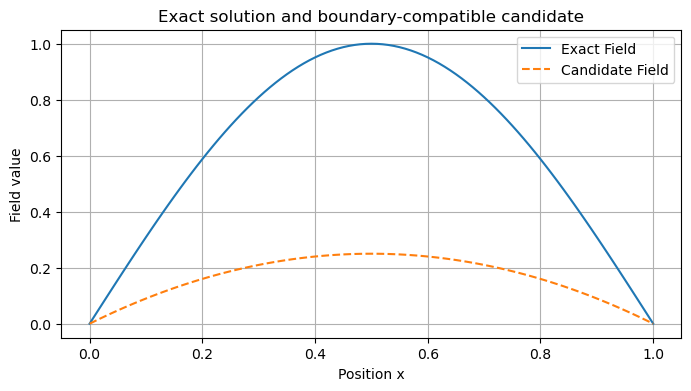

In [76]:
plt.figure(figsize=(8,4))

plt.plot(x_second_derivative, u_values, label = "Exact Field")
plt.plot(x_second_derivative, candidate_values, "--", label = "Candidate Field")

plt.xlabel("Position x")
plt.ylabel("Field value")
plt.title("Exact solution and boundary-compatible candidate")

plt.grid(True)
plt.legend()
plt.show()

# u(x) = sin(pi * x)
# u_c(x) = x*(1-x)

# The candidate field satisfies the boundary conditions, but its larger physics loss shows that it does not satisfy the governing differential equation
# The plot connects the visual shape of the functions with the loss calculations

## Lecture 1 - Guided Section Summary

In this lecture, learned to do how to:

- create and use Python variables,
- work with numbers, strings, and Boolean values,
- use `if`, `elif`, and `else`,
- write `for` and `while` loops,
- define and call functions,
- validate function inputs,
- create and manipulate NumPy arrays,
- use indexing, slicing, reshaping, and Boolean masks,
- perform vectorized calculations,
- create numerical grids using `np.linspace`,
- plot physical fields using Matplotlib,
- approximate first and second derivatives using finite differences,
- compare numerical derivatives with analytical derivatives,
- calculate the residual of a differential equation,
- construct physics and boundary-condition losses.

### Differential-equation residual

The differential-equation residual measures how strongly a candidate function violates the governing equation.

For the governing equation

$$
u''(x) + \pi^2 u(x) = 0,
$$

the physics residual is

$$
r_{\mathrm{physics}}(x)
=
u''(x) + \pi^2 u(x).
$$

For an exact solution, the residual is zero:

$$
r_{\mathrm{physics}}(x)=0.
$$

### Physics loss

The physics loss is the mean squared value of the residual over the selected domain points:

$$
\mathcal{L}_{\mathrm{physics}}
=
\frac{1}{N}
\sum_{i=1}^{N}
r_{\mathrm{physics}}(x_i)^2.
$$

A small physics loss means that the candidate function approximately satisfies the governing differential equation.

### Boundary-condition loss

The boundary residual compares the predicted boundary values with the required boundary values:

$$
r_{\mathrm{boundary}}(x_i)
=
u(x_i)-u_{\mathrm{required}}(x_i).
$$

The boundary loss is

$$
\mathcal{L}_{\mathrm{boundary}}
=
\frac{1}{N_b}
\sum_{i=1}^{N_b}
\left[
u(x_i)-u_{\mathrm{required}}(x_i)
\right]^2.
$$

A small boundary loss means that the candidate function approximately satisfies the prescribed boundary conditions.

### Total physics-informed loss

The total loss combines the physics and boundary losses:

$$
\mathcal{L}_{\mathrm{total}}
=
\mathcal{L}_{\mathrm{physics}}
+
\mathcal{L}_{\mathrm{boundary}}.
$$

A function may satisfy the boundary conditions without satisfying the governing differential equation. Therefore, both loss terms are required.